<a href="https://colab.research.google.com/github/SreeHarshiniR/ANN-Classwork/blob/main/HR_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HR Attrition Prediction Project
Streamlit + Machine Learning Project

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv("(Task) HR_comma_sep.csv")

# -----------------------------------
# INPUT FEATURES
# -----------------------------------

X = df.drop('left', axis=1)

# TARGET
y = df['left']

# -----------------------------------
# CONVERT TEXT TO NUMBERS
# -----------------------------------

X = pd.get_dummies(X, drop_first=True)

# -----------------------------------
# TRAIN TEST SPLIT
# -----------------------------------


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------------
# MODEL
# -----------------------------------

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# -----------------------------------
# DATASET PREDICTIONS
# -----------------------------------

dataset_predictions = model.predict(X)

# -----------------------------------
# ACCURACY
# -----------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(round(accuracy * 100,2), "%")

# -----------------------------------
# INITIALIZED EMPLOYEE INPUT
# -----------------------------------


Accuracy:
78.23 %


C:\Users\rajesh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Initialized Employee Prediction:
Employee Will Stay


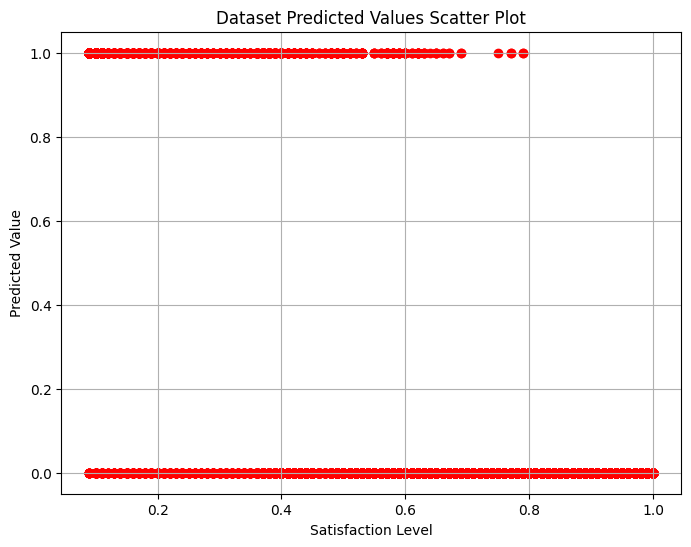

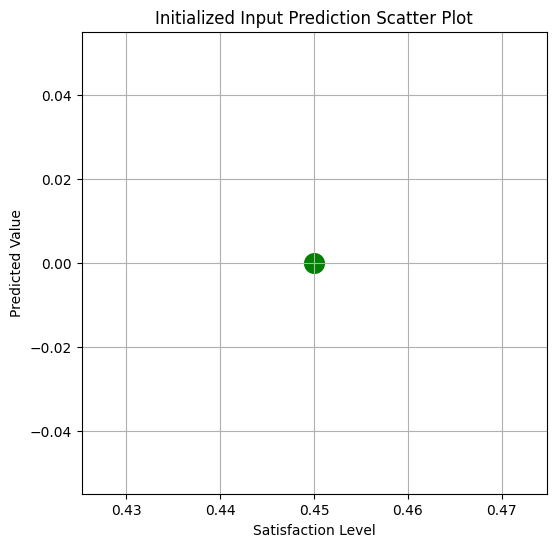

In [ ]:
sample_employee = [[
    0.45,   # satisfaction_level
    0.80,   # last_evaluation
    3,      # number_project
    160,    # average_monthly_hours
    3,      # time_spend_company
    0,      # Work_accident
    0,      # promotion_last_5years
    0,0,0,0,0,0,0,0,0,
    1,0
]]

sample_prediction = model.predict(sample_employee)

print("\nInitialized Employee Prediction:")

if sample_prediction[0] == 1:
    print("Employee Will Leave")
else:
    print("Employee Will Stay")

# ===================================
# GRAPH 1
# DATASET PREDICTED VALUES
# ===================================

plt.figure(figsize=(8,6))

plt.scatter(
    df['satisfaction_level'],
    dataset_predictions,
    color='red'
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Predicted Value")

plt.title("Dataset Predicted Values Scatter Plot")
plt.grid(True)

plt.show()

# ===================================
# GRAPH 2
# INITIALIZED INPUT PREDICTION
# ===================================

plt.figure(figsize=(6,6))

plt.scatter(
    sample_employee[0][0],
    sample_prediction[0],
    color='green',
    s=200
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Predicted Value")

plt.title("Initialized Input Prediction Scatter Plot")

plt.grid(True)

plt.show()

C:\Users\rajesh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


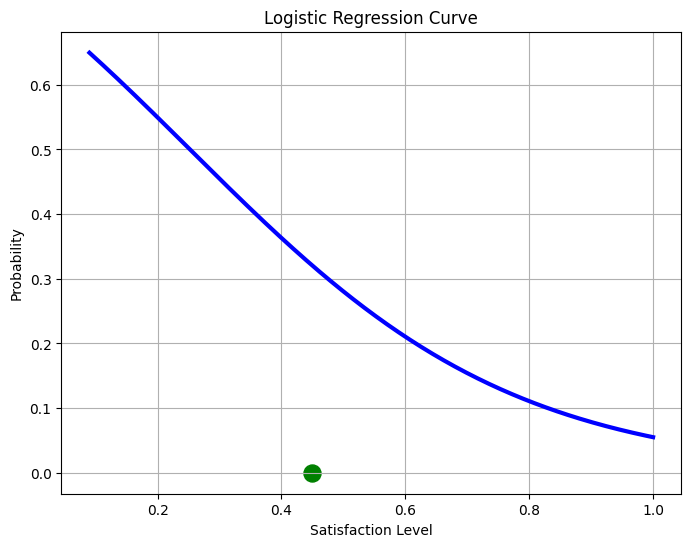

In [ ]:
# ===================================
# GRAPH 3
# LOGISTIC REGRESSION CURVE
# ===================================

X_graph = df[['satisfaction_level']]

y_graph = df['left']

graph_model = LogisticRegression()

graph_model.fit(X_graph, y_graph)

x_range = np.linspace(
    df.satisfaction_level.min(),
    df.satisfaction_level.max(),
    300
).reshape(-1,1)

y_curve = graph_model.predict_proba(
    x_range
)[:,1]

plt.figure(figsize=(8,6))

plt.plot(
    x_range,
    y_curve,
    color='blue',
    linewidth=3
)

plt.scatter(
    sample_employee[0][0],
    sample_prediction[0],
    color='green',
    s=150
)

plt.xlabel("Satisfaction Level")
plt.ylabel("Probability")
plt.title("Logistic Regression Curve")

plt.grid(True)

plt.show()